In [2]:
# ============================================================
# COLLECT ALL RESULTS -> MASTER CSV + LABELED PDF
# ============================================================

import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image, ImageOps, ImageDraw, ImageFont

# ============================================================
# 1. PATHS
# ============================================================
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = ROOT / "results"
OUTPUT_DIR = ROOT / "results" / "final_compiled_report"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_CSV = OUTPUT_DIR / "all_experiment_results.csv"
PDF_PATH = OUTPUT_DIR / "all_result_images_labeled.pdf"

print("ROOT:", ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not RESULTS_ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {RESULTS_ROOT}")

# ============================================================
# 2. COLLECT ALL METRICS.JSON FILES
# ============================================================
metrics_files = sorted(RESULTS_ROOT.rglob("metrics.json"))
print("\nmetrics.json found:", len(metrics_files))

if len(metrics_files) == 0:
    raise ValueError("No metrics.json files found inside results/")

# ============================================================
# 3. BUILD MASTER CSV
# ============================================================
rows = []

for mf in metrics_files:
    try:
        with open(mf, "r") as f:
            m = json.load(f)
    except Exception as e:
        print("Skipping unreadable metrics file:", mf, "|", e)
        continue

    row = {
        "metrics_path": str(mf),
        "run_dir": str(mf.parent),
        "protocol_name": m.get("protocol_name"),
        "frame_source": m.get("frame_source", m.get("train_modality")),
        "train_modality": m.get("train_modality"),
        "test_modality": m.get("test_modality"),
        "model_name": m.get("model_name"),
        "num_sample_frames": m.get("num_sample_frames"),
        "batch_size": m.get("batch_size"),
        "best_epoch": m.get("best_epoch"),
        "best_val_macro_f1": m.get("best_val_macro_f1"),
        "test_accuracy": m.get("test_accuracy"),
        "test_macro_f1": m.get("test_macro_f1"),
        "test_weighted_f1": m.get("test_weighted_f1"),
        "train_time_minutes": m.get("train_time_minutes"),
        "inference_time_seconds": m.get("inference_time_seconds"),
        "videos_per_second": m.get("videos_per_second"),
        "train_rows": m.get("train_rows"),
        "val_rows": m.get("val_rows"),
        "test_rows": m.get("test_rows"),
        "predictions_csv": m.get("predictions_csv"),
        "classification_report_csv": m.get("classification_report_csv"),
        "confusion_matrix_png": m.get("confusion_matrix_png"),
        "checkpoint_best": m.get("checkpoint_best"),
    }

    per_class = m.get("per_class_f1", {})
    if isinstance(per_class, dict):
        for k, v in per_class.items():
            row[f"f1_{k}"] = v

    # fallback parsing from folder name
    if row["protocol_name"] is None or row["model_name"] is None:
        parts = mf.parent.name.split("__")
        if len(parts) >= 3:
            row["protocol_name"] = row["protocol_name"] or parts[0]
            row["model_name"] = row["model_name"] or parts[-3]

    rows.append(row)

master_df = pd.DataFrame(rows)

if len(master_df) == 0:
    raise ValueError("No valid metrics rows could be created.")

# numeric cleanup
numeric_cols = [
    "num_sample_frames", "batch_size", "best_epoch",
    "best_val_macro_f1", "test_accuracy", "test_macro_f1", "test_weighted_f1",
    "train_time_minutes", "inference_time_seconds", "videos_per_second",
    "train_rows", "val_rows", "test_rows"
]
for c in numeric_cols:
    if c in master_df.columns:
        master_df[c] = pd.to_numeric(master_df[c], errors="coerce")

master_df = master_df.sort_values(
    by=["protocol_name", "model_name", "test_macro_f1"],
    ascending=[True, True, False]
).reset_index(drop=True)

master_df.to_csv(MASTER_CSV, index=False)
print("\nSaved MASTER CSV:", MASTER_CSV)
print("Master shape:", master_df.shape)

# ============================================================
# 4. COLLECT IMAGES FOR PDF
# ============================================================
# Priority:
#   1. confusion_matrix.png
#   2. any png/jpg/jpeg in result folders
# Each page gets a title label
# ============================================================
image_entries = []

for _, row in master_df.iterrows():
    run_dir = Path(row["run_dir"])

    protocol_name = str(row.get("protocol_name", "unknown_protocol"))
    model_name = str(row.get("model_name", "unknown_model"))
    frame_source = str(row.get("frame_source", row.get("train_modality", "unknown_source")))
    train_modality = str(row.get("train_modality", ""))
    test_modality = str(row.get("test_modality", ""))

    title = f"Protocol: {protocol_name} | Model: {model_name}"
    if train_modality != "None" and test_modality != "None" and train_modality and test_modality:
        title += f" | Train: {train_modality} | Test: {test_modality}"
    elif frame_source and frame_source != "nan":
        title += f" | Source: {frame_source}"

    subtitle = (
        f"Acc={row.get('test_accuracy', np.nan):.4f} | "
        f"MacroF1={row.get('test_macro_f1', np.nan):.4f} | "
        f"WeightedF1={row.get('test_weighted_f1', np.nan):.4f}"
    )

    # confusion matrix first
    cm_path = row.get("confusion_matrix_png", None)
    if pd.notna(cm_path) and cm_path:
        cm_path = Path(cm_path)
        if cm_path.exists():
            image_entries.append({
                "image_path": cm_path,
                "title": title,
                "subtitle": subtitle + " | Image: confusion_matrix"
            })

    # optional other result images
    extra_imgs = []
    for ext in ["*.png", "*.jpg", "*.jpeg"]:
        extra_imgs.extend(sorted(run_dir.glob(ext)))

    # remove confusion matrix duplicate
    extra_imgs = [p for p in extra_imgs if str(p) != str(cm_path)] if pd.notna(cm_path) and cm_path else extra_imgs

    for p in extra_imgs:
        image_entries.append({
            "image_path": p,
            "title": title,
            "subtitle": subtitle + f" | Image: {p.name}"
        })

print("\nImages collected for PDF:", len(image_entries))

if len(image_entries) == 0:
    print("No images found. CSV is created, but PDF will not be created.")
else:
    # ============================================================
    # 5. CREATE LABELED PDF
    # ============================================================
    def safe_font(size=28):
        # notebook/server may not have custom fonts, so fallback safely
        try:
            return ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", size)
        except:
            return ImageFont.load_default()

    title_font = safe_font(28)
    subtitle_font = safe_font(20)

    pages = []

    for idx, item in enumerate(image_entries):
        img_path = item["image_path"]
        title = item["title"]
        subtitle = item["subtitle"]

        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print("Skipping unreadable image:", img_path, "|", e)
            continue

        # page settings
        page_w = 1654   # approx A4 landscape-ish @ 150-170 dpi
        page_h = 1169
        margin = 40
        text_area_h = 150

        page = Image.new("RGB", (page_w, page_h), "white")
        draw = ImageDraw.Draw(page)

        # draw title/subtitle
        draw.text((margin, 20), title, fill="black", font=title_font)
        draw.text((margin, 70), subtitle, fill="black", font=subtitle_font)
        draw.line((margin, 120, page_w - margin, 120), fill="black", width=2)

        # fit image
        max_w = page_w - 2 * margin
        max_h = page_h - text_area_h - margin

        img.thumbnail((max_w, max_h))
        x = (page_w - img.width) // 2
        y = text_area_h + (max_h - img.height) // 2

        page.paste(img, (x, y))
        pages.append(page)

    if len(pages) > 0:
        pages[0].save(PDF_PATH, save_all=True, append_images=pages[1:])
        print("Saved labeled PDF:", PDF_PATH)
    else:
        print("No valid pages could be created for PDF.")

# ============================================================
# 6. DISPLAY QUICK TABLES
# ============================================================
print("\n========== MASTER RESULTS ==========")
display(master_df[[
    "protocol_name",
    "model_name",
    "train_modality",
    "test_modality",
    "frame_source",
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "train_time_minutes",
    "videos_per_second"
]].head(100))

best_df = master_df.loc[
    master_df.groupby(
        ["protocol_name", "train_modality", "test_modality", "frame_source"],
        dropna=False
    )["test_macro_f1"].idxmax()
].reset_index(drop=True)

print("\n========== BEST RESULT PER PROTOCOL ==========")
display(best_df[[
    "protocol_name",
    "model_name",
    "train_modality",
    "test_modality",
    "frame_source",
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1"
]].sort_values(["protocol_name", "test_macro_f1"], ascending=[True, False]))

print("\nDONE.")
print("CSV :", MASTER_CSV)
print("PDF :", PDF_PATH if len(image_entries) > 0 else "No PDF created")

ROOT: /data/Sajjan_Singh/gesture_recognition
RESULTS_ROOT: /data/Sajjan_Singh/gesture_recognition/results
OUTPUT_DIR: /data/Sajjan_Singh/gesture_recognition/results/final_compiled_report

metrics.json found: 353

Saved MASTER CSV: /data/Sajjan_Singh/gesture_recognition/results/final_compiled_report/all_experiment_results.csv
Master shape: (353, 31)

Images collected for PDF: 297
Saved labeled PDF: /data/Sajjan_Singh/gesture_recognition/results/final_compiled_report/all_result_images_labeled.pdf

========== MASTER RESULTS ==========


,protocol_name,model_name,train_modality,test_modality,frame_source,test_accuracy,test_macro_f1,test_weighted_f1,train_time_minutes,videos_per_second
0,protocol_A,convnext_tiny,None,None,RGB_BGREM,0.884354,0.882956,0.882956,41.721334,2.635442
1,protocol_A,convnext_tiny,None,None,RGB,0.843537,0.846039,0.846039,70.546853,1.831192
2,protocol_A,convnext_tiny,RGB,NIR,RGB,0.421769,0.350680,0.350680,39.857117,11.084656
3,protocol_A,efficientnet_b0,None,None,RGB,0.884354,0.885118,0.885118,133.153143,1.139901
4,protocol_A,efficientnet_b0,None,None,RGB,0.884354,0.885118,0.885118,135.243664,0.972483
...,...,...,...,...,...,...,...,...,...,...
95,protocol_B_4_6_to_8,convnext_tiny,RGB,NIR,RGB,0.338346,0.296477,0.296477,15.879005,17.219986
96,protocol_B_4_6_to_8,efficientnet_b0,None,None,RGB,0.627820,0.628604,0.628604,63.282597,0.695280
97,protocol_B_4_6_to_8,efficientnet_b0,None,None,RGB_BGREM,0.624060,0.624181,0.624181,98.401112,0.410089
98,protocol_B_4_6_to_8,efficientnet_b0,None,None,RGB,0.560150,0.559856,0.559856,67.651529,0.680196



========== BEST RESULT PER PROTOCOL ==========


,protocol_name,model_name,train_modality,test_modality,frame_source,test_accuracy,test_macro_f1,test_weighted_f1
1,protocol_A,efficientnet_b0,None,None,RGB,0.884354,0.885118,0.885118
2,protocol_A,convnext_tiny,None,None,RGB_BGREM,0.884354,0.882956,0.882956
0,protocol_A,convnext_tiny,RGB,NIR,RGB,0.421769,0.350680,0.350680
5,protocol_B_4_6_8_to_4,resnet18,None,None,RGB_BGREM,0.991597,0.991595,0.991595
4,protocol_B_4_6_8_to_4,vit_b_16,None,None,RGB,0.987395,0.987392,0.987392
...,...,...,...,...,...,...,...,...
64,protocol_B_8_to_8,convnext_tiny,None,None,RGB,0.969925,0.970133,0.970133
65,protocol_B_8_to_8,efficientnet_b0,None,None,RGB_BGREM,0.958647,0.958539,0.958539
63,protocol_B_8_to_8,convnext_tiny,RGB,NIR,RGB,0.364662,0.308082,0.308082
66,None,efficientnet_b0,None,None,RGB,0.843537,0.848583,NaN



DONE.
CSV : /data/Sajjan_Singh/gesture_recognition/results/final_compiled_report/all_experiment_results.csv
PDF : /data/Sajjan_Singh/gesture_recognition/results/final_compiled_report/all_result_images_labeled.pdf


ROOT: /data/Sajjan_Singh/gesture_recognition
CSV : /data/Sajjan_Singh/gesture_recognition/results/final_compiled_report/all_experiment_results.csv
OUT : /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs

Loaded shape: (353, 31)


,metrics_path,run_dir,protocol_name,frame_source,train_modality,test_modality,model_name,num_sample_frames,batch_size,best_epoch,best_val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,train_time_minutes,inference_time_seconds,videos_per_second,train_rows,val_rows,test_rows,predictions_csv,classification_report_csv,confusion_matrix_png,checkpoint_best,f1_doctor,f1_emergency,f1_fire,f1_help,f1_robbery,f1_sit_down,f1_stand_up
0,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224,protocol_A,RGB_BGREM,NaN,NaN,convnext_tiny,32.0,24.0,9,0.895918,0.884354,0.882956,0.882956,41.721334,55.778125,2.635442,525.0,77.0,147.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/test_predictions.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/classification_report.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/confusion_matrix.png,/data/Sajjan_Singh/gesture_recognition/checkpoints/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/best_model.pt,1.000000,0.923077,0.933333,0.976744,0.950000,0.631579,0.765957
1,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb__convnext_tiny__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb__convnext_tiny__f32__img224,protocol_A,RGB,NaN,NaN,convnext_tiny,32.0,12.0,7,0.921429,0.843537,0.846039,0.846039,70.546853,80.275568,1.831192,525.0,77.0,147.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb__convnext_tiny__f32__img224/test_predictions.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb__convnext_tiny__f32__img224/classification_report.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb__convnext_tiny__f32__img224/confusion_matrix.png,/data/Sajjan_Singh/gesture_recognition/checkpoints/stage5_vit_convnext/protocol_A__rgb__convnext_tiny__f32__img224/best_model.pt,0.950000,0.864865,0.875000,0.975610,0.871795,0.619048,0.765957
2,/data/Sajjan_Singh/gesture_recognition/results/rgb_train_thermal_test_5models/protocol_A__rgb_train__thermal_test__convnext_tiny__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/rgb_train_thermal_test_5models/protocol_A__rgb_train__thermal_test__convnext_tiny__f32__img224,protocol_A,RGB,RGB,NIR,convnext_tiny,32.0,10.0,3,0.895889,0.421769,0.350680,0.350680,39.857117,13.261575,11.084656,525.0,77.0,147.0,/data/Sajjan_Singh/gesture_recognition/results/rgb_train_thermal_test_5models/protocol_A__rgb_train__thermal_test__convnext_tiny__f32__img224/test_predictions.csv,/data/Sajjan_Singh/gesture_recognition/results/rgb_train_thermal_test_5models/protocol_A__rgb_train__thermal_test__convnext_tiny__f32__img224/classification_report.csv,/data/Sajjan_Singh/gesture_recognition/results/rgb_train_thermal_test_5models/protocol_A__rgb_train__thermal_test__convnext_tiny__f32__img224/confusion_matrix.png,/data/Sajjan_Singh/gesture_recognition/checkpoints/rgb_train_thermal_test_5models/protocol_A__rgb_train__thermal_test__convnext_tiny__f32__img224/best_model.pt,0.000000,0.512821,0.542373,0.240000,0.441176,0.551724,0.166667
3,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224,protocol_A,RGB,NaN,NaN,efficientnet_b0,NaN,NaN,11,0.841927,0.884354,0.885118,0.885118,133.153143,128.958593,1.139901,525.0,77.0,147.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol


Setting counts:


setting_group
RGB          240
RGB_BGREM    110
Name: count, dtype: int64


Best per protocol + setting:


,protocol_name,setting_group,metrics_path,run_dir,frame_source,train_modality,test_modality,model_name,num_sample_frames,batch_size,best_epoch,best_val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,train_time_minutes,inference_time_seconds,videos_per_second,train_rows,val_rows,test_rows,predictions_csv,classification_report_csv,confusion_matrix_png,checkpoint_best,f1_doctor,f1_emergency,f1_fire,f1_help,f1_robbery,f1_sit_down,f1_stand_up
0,protocol_A,RGB,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224,RGB,RGB,NIR,efficientnet_b0,32.0,12.0,11,0.841927,0.884354,0.885118,0.885118,133.153143,128.958593,1.139901,525.0,77.0,147.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224/test_predictions.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224/classification_report.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224/confusion_matrix.png,/data/Sajjan_Singh/gesture_recognition/checkpoints/stage5_rgb_benchmark/protocol_A__rgb__efficientnet_b0__f32__img224/best_model.pt,0.976744,0.904762,0.909091,0.975610,0.894737,0.744186,0.790698
1,protocol_A,RGB_BGREM,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224,RGB_BGREM,None,None,convnext_tiny,32.0,24.0,9,0.895918,0.884354,0.882956,0.882956,41.721334,55.778125,2.635442,525.0,77.0,147.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/test_predictions.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/classification_report.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/confusion_matrix.png,/data/Sajjan_Singh/gesture_recognition/checkpoints/stage5_vit_convnext/protocol_A__rgb_bgrem__convnext_tiny__f32__img224/best_model.pt,1.000000,0.923077,0.933333,0.976744,0.950000,0.631579,0.765957
2,protocol_B_4_6_8_to_4,RGB,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_B_4_6_8_to_4__rgb__vit_b_16__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_B_4_6_8_to_4__rgb__vit_b_16__f32__img224,RGB,RGB,NIR,vit_b_16,32.0,16.0,8,0.864448,0.987395,0.987392,0.987392,49.298574,35.129191,6.774992,675.0,74.0,238.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_B_4_6_8_to_4__rgb__vit_b_16__f32__img224/test_predictions.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_B_4_6_8_to_4__rgb__vit_b_16__f32__img224/classification_report.csv,/data/Sajjan_Singh/gesture_recognition/results/stage5_vit_convnext/protocol_B_4_6_8_to_4__rgb__vit_b_16__f32__img224/confusion_matrix.png,/data/Sajjan_Singh/gesture_recognition/checkpoints/stage5_vit_convnext/protocol_B_4_6_8_to_4__rgb__vit_b_16__f32__img224/best_model.pt,1.000000,1.000000,1.000000,1.000000,1.000000,0.955224,0.956522
3,protocol_B_4_6_8_to_4,RGB_BGREM,/data/Sajjan_Singh/gesture_recognition/results/stage5_resume_all/protocol_B_4_6_8_to_4__rgb_bgrem__resnet18__f32__img224/metrics.json,/data/Sajjan_Singh/gesture_recognition/results/stage5_resume_all/protocol_B_4_6_8_to_4__rgb_bgrem__resnet18__f32__img224,RGB_BGREM,None,None,resnet18,32.0,24.0,8,0.805096,0.991597,0.991595,0.991595,36.384375,30.622916,7.771957,675.0,74.0,238.0,/data/Sajjan_Singh/gesture_recognition/results/stage5_resume_all/protocol_B_4_6_8_to_4__rgb_bgrem__resnet18__f32__img224/test_pre


Protocol-wise pivot:


setting_group,RGB,RGB_BGREM,RGB->NIR
protocol_name,,,
protocol_A,0.884354,0.884354,NaN
protocol_B_4_to_4,0.987395,0.974790,NaN
protocol_B_4_to_6,0.853061,0.844898,NaN
protocol_B_4_to_8,0.601504,0.669173,NaN
protocol_B_6_to_4,0.815126,0.815126,NaN
protocol_B_6_to_6,0.987755,0.995918,NaN
protocol_B_6_to_8,0.642857,0.661654,NaN
protocol_B_8_to_4,0.542017,0.609244,NaN
protocol_B_8_to_6,0.730612,0.730612,NaN


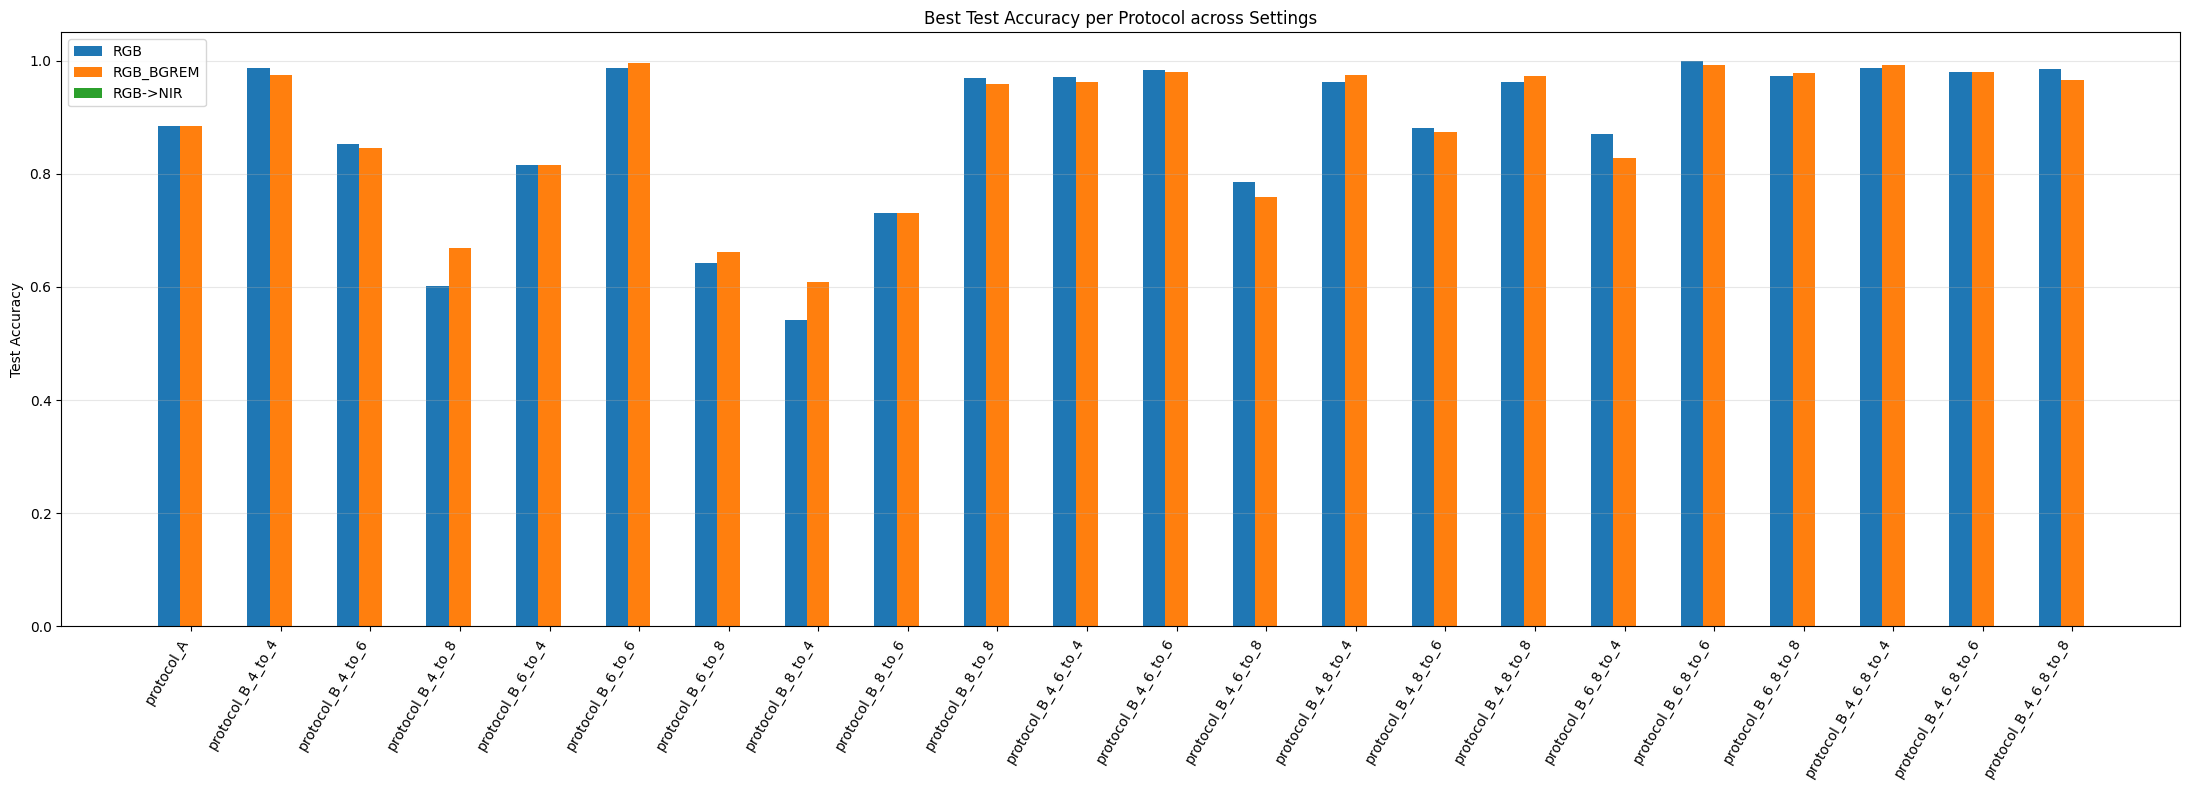

Saved: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs/protocolwise_grouped_bar_test_accuracy.png


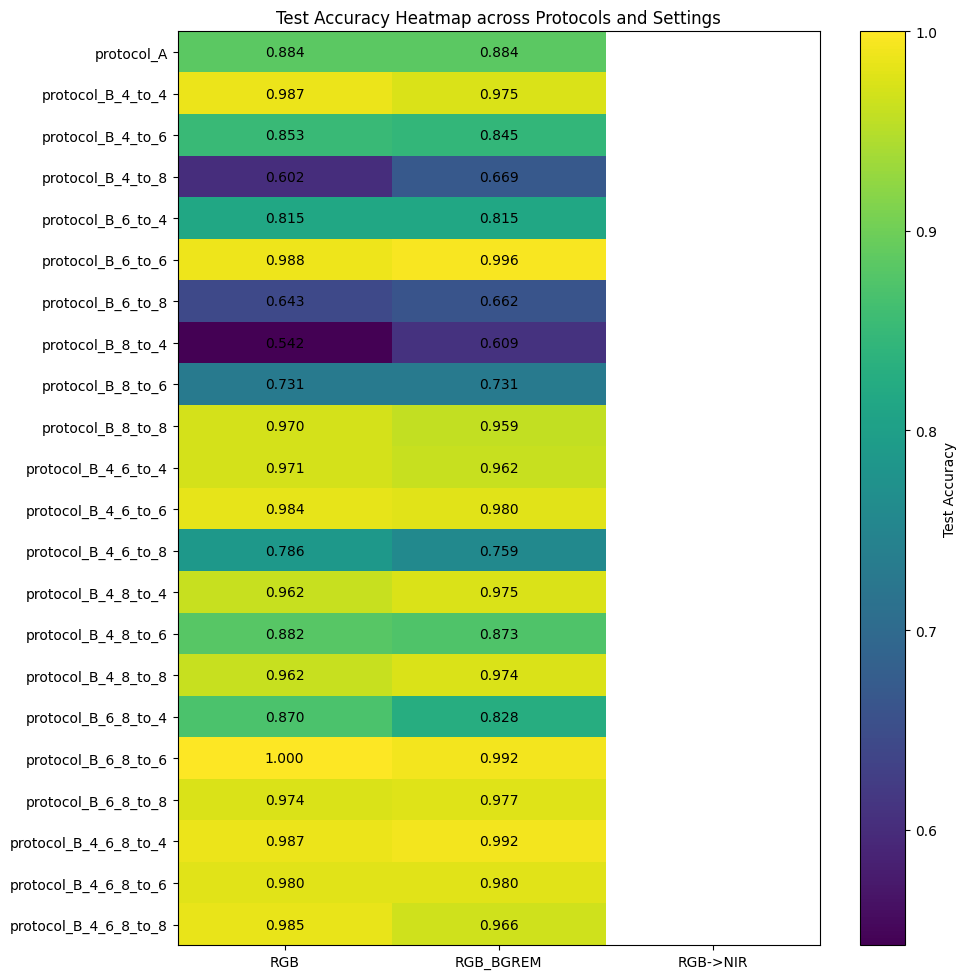

Saved: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs/protocolwise_heatmap_test_accuracy.png


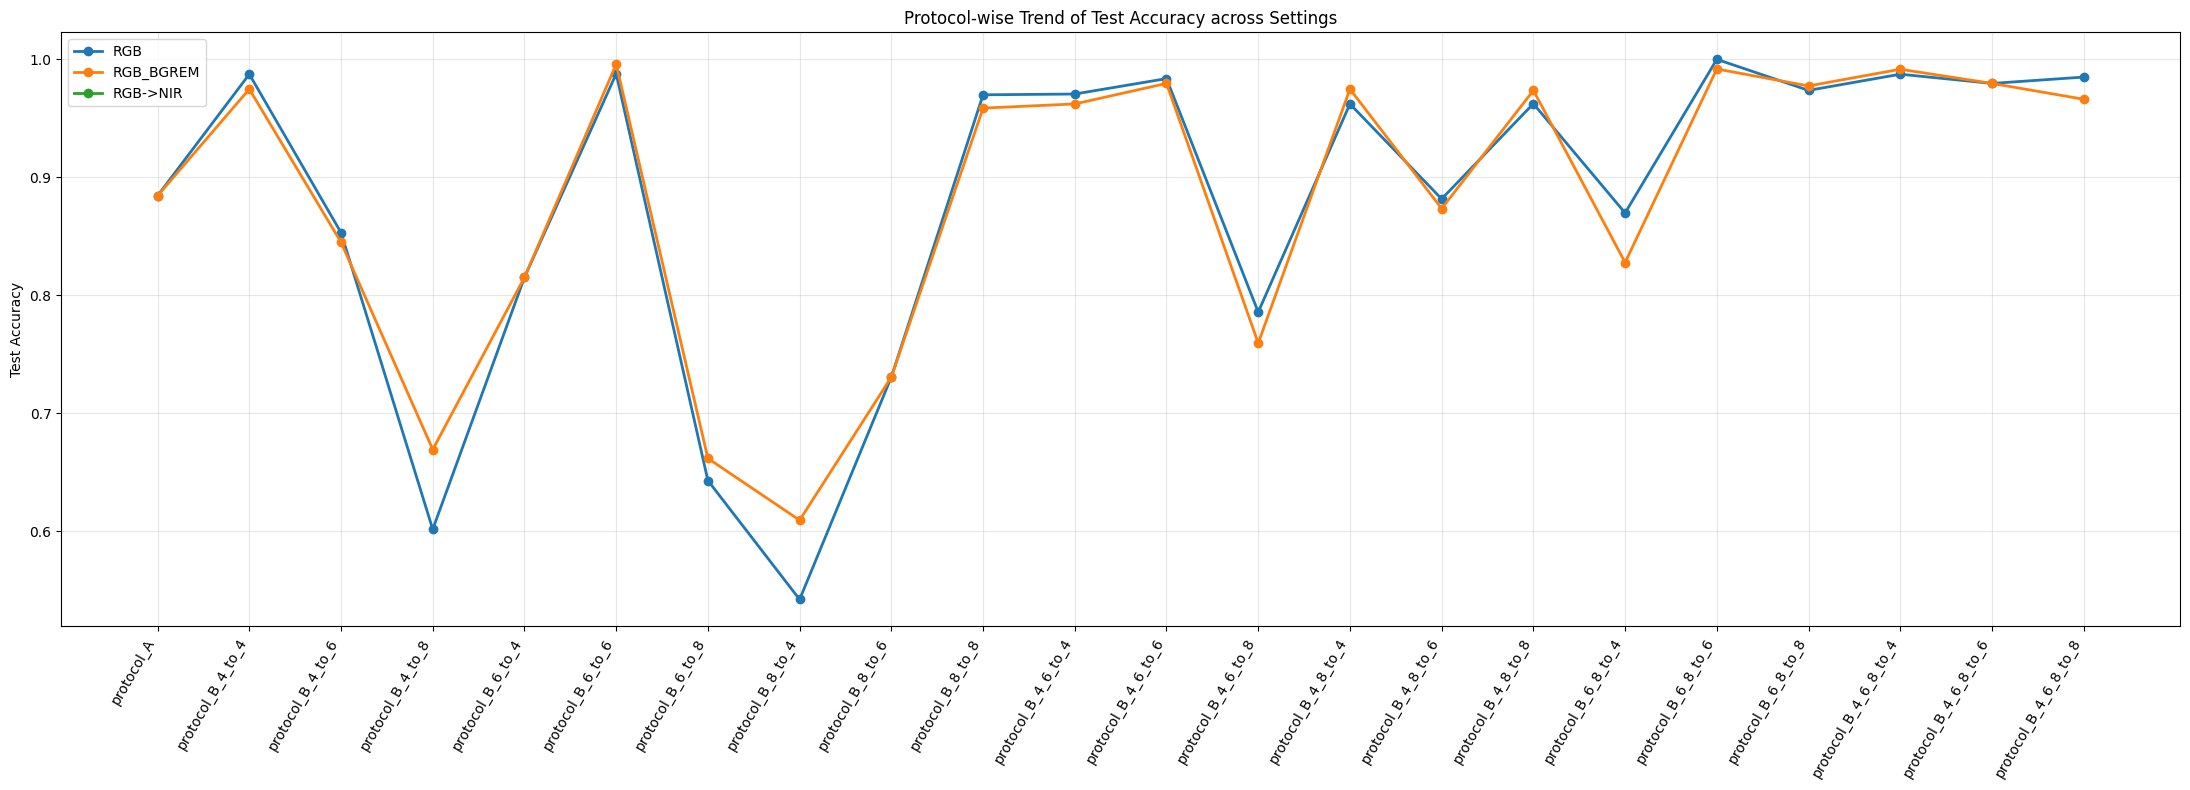

Saved: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs/protocolwise_lineplot_test_accuracy.png

Average test accuracy by model and setting:


setting_group,RGB,RGB_BGREM,RGB->NIR
model_name,,,
convnext_tiny,0.872139,0.863641,NaN
efficientnet_b0,0.783558,0.806764,NaN
mobilenet_v3_small,0.513363,0.472065,NaN
resnet18,0.765044,0.799275,NaN
vit_b_16,0.670760,0.829846,NaN


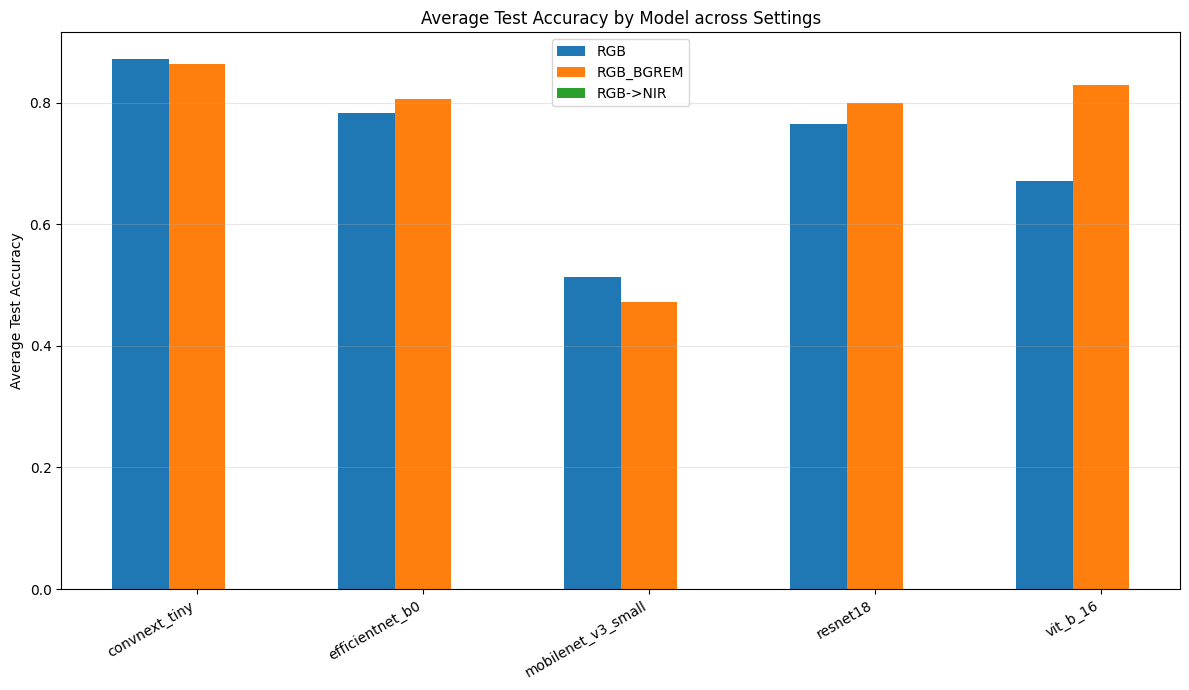

Saved: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs/modelwise_grouped_bar_test_accuracy.png

Accuracy drop table:


setting_group,RGB,RGB_BGREM,RGB->NIR,drop_RGB_to_NIR,drop_BGREM_to_NIR
protocol_name,,,,,
protocol_A,0.884354,0.884354,NaN,NaN,NaN
protocol_B_4_to_4,0.987395,0.974790,NaN,NaN,NaN
protocol_B_4_to_6,0.853061,0.844898,NaN,NaN,NaN
protocol_B_4_to_8,0.601504,0.669173,NaN,NaN,NaN
protocol_B_6_to_4,0.815126,0.815126,NaN,NaN,NaN
protocol_B_6_to_6,0.987755,0.995918,NaN,NaN,NaN
protocol_B_6_to_8,0.642857,0.661654,NaN,NaN,NaN
protocol_B_8_to_4,0.542017,0.609244,NaN,NaN,NaN
protocol_B_8_to_6,0.730612,0.730612,NaN,NaN,NaN


Saved: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs/protocolwise_accuracy_drop_vs_nir.csv

Saved summary CSV: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs/best_per_protocol_per_setting_long.csv

DONE.
Files saved in: /data/Sajjan_Singh/gesture_recognition/results/comparison_graphs


In [ ]:
# ============================================================
# COMPARE ALL RESULTS ON GRAPHS
# RGB vs RGB_BGREM vs RGB->THERMAL USING TEST ACCURACY
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)

# ============================================================
# 1. PATHS
# ============================================================
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

CSV_CANDIDATES = [
    ROOT / "results" / "final_compiled_report" / "all_experiment_results.csv",
    ROOT / "results" / "intermediate_report_bundle" / "master_experiment_results.csv",
    ROOT / "results" / "rgb_train_thermal_test_5models" / "rgb_train_thermal_test_5models_summary.csv",
]

csv_path = None
for p in CSV_CANDIDATES:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError(
        "No result CSV found in expected locations. Please set csv_path manually."
    )

OUTPUT_DIR = ROOT / "results" / "comparison_graphs_thermal_named"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("CSV :", csv_path)
print("OUT :", OUTPUT_DIR)

# ============================================================
# 2. LOAD CSV
# ============================================================
df = pd.read_csv(csv_path)
print("\nLoaded shape:", df.shape)
display(df.head())

# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================
required_any = ["protocol_name", "model_name", "test_accuracy"]
for c in required_any:
    if c not in df.columns:
        raise ValueError(f"Required column missing: {c}")

# ============================================================
# 4. NORMALIZE SETTING LABELS
# IMPORTANT: display label is THERMAL, not NIR
# ============================================================
def infer_setting(row):
    frame_source = str(row.get("frame_source", "")).strip()
    train_modality = str(row.get("train_modality", "")).strip()
    test_modality = str(row.get("test_modality", "")).strip()

    if frame_source == "RGB":
        return "RGB"
    if frame_source == "RGB_BGREM":
        return "RGB_BGREM"

    # Any cross-modality RGB -> NIR/Thermal is displayed as RGB->Thermal
    if train_modality == "RGB" and test_modality.upper() in ["NIR", "THERMAL"]:
        return "RGB->Thermal"

    # fallback logic
    if "RGB_BGREM" in frame_source:
        return "RGB_BGREM"
    if train_modality == "RGB" and ("NIR" in test_modality.upper() or "THERMAL" in test_modality.upper()):
        return "RGB->Thermal"
    if frame_source == "RGB":
        return "RGB"

    return "OTHER"

df["setting_group"] = df.apply(infer_setting, axis=1)

df_plot = df[df["setting_group"].isin(["RGB", "RGB_BGREM", "RGB->Thermal"])].copy()

print("\nSetting counts:")
display(df_plot["setting_group"].value_counts(dropna=False))

# ============================================================
# 5. CLEAN NUMERIC COLUMNS
# ============================================================
df_plot["test_accuracy"] = pd.to_numeric(df_plot["test_accuracy"], errors="coerce")
if "test_macro_f1" in df_plot.columns:
    df_plot["test_macro_f1"] = pd.to_numeric(df_plot["test_macro_f1"], errors="coerce")

df_plot = df_plot.dropna(subset=["protocol_name", "model_name", "test_accuracy"]).copy()

# ============================================================
# 6. HANDLE DUPLICATES
# ============================================================
best_protocol_setting = (
    df_plot.sort_values("test_accuracy", ascending=False)
    .groupby(["protocol_name", "setting_group"], as_index=False)
    .first()
)

best_protocol_setting_model = (
    df_plot.sort_values("test_accuracy", ascending=False)
    .groupby(["protocol_name", "setting_group", "model_name"], as_index=False)
    .first()
)

print("\nBest per protocol + setting:")
display(best_protocol_setting.head(20))

# ============================================================
# 7. ORDER PROTOCOLS
# ============================================================
preferred_protocol_order = [
    "protocol_A",
    "protocol_B_4_to_4",
    "protocol_B_4_to_6",
    "protocol_B_4_to_8",
    "protocol_B_6_to_4",
    "protocol_B_6_to_6",
    "protocol_B_6_to_8",
    "protocol_B_8_to_4",
    "protocol_B_8_to_6",
    "protocol_B_8_to_8",
    "protocol_B_4_6_to_4",
    "protocol_B_4_6_to_6",
    "protocol_B_4_6_to_8",
    "protocol_B_4_8_to_4",
    "protocol_B_4_8_to_6",
    "protocol_B_4_8_to_8",
    "protocol_B_6_8_to_4",
    "protocol_B_6_8_to_6",
    "protocol_B_6_8_to_8",
    "protocol_B_4_6_8_to_4",
    "protocol_B_4_6_8_to_6",
    "protocol_B_4_6_8_to_8",
]

present_protocols = best_protocol_setting["protocol_name"].unique().tolist()
ordered_protocols = [p for p in preferred_protocol_order if p in present_protocols] + \
                    [p for p in present_protocols if p not in preferred_protocol_order]

setting_order = ["RGB", "RGB_BGREM", "RGB->Thermal"]

# ============================================================
# 8. PIVOT FOR PROTOCOL-WISE COMPARISON
# ============================================================
pivot_protocol = best_protocol_setting.pivot(
    index="protocol_name",
    columns="setting_group",
    values="test_accuracy"
).reindex(index=ordered_protocols, columns=setting_order)

print("\nProtocol-wise pivot:")
display(pivot_protocol)

pivot_protocol.to_csv(OUTPUT_DIR / "protocol_setting_test_accuracy_pivot.csv")

# ============================================================
# 9. GRAPH 1: GROUPED BAR CHART
# ============================================================
fig, ax = plt.subplots(figsize=(22, 8))

x = np.arange(len(pivot_protocol.index))
bar_w = 0.25

for i, setting in enumerate(setting_order):
    vals = pivot_protocol[setting].values
    ax.bar(x + (i - 1) * bar_w, vals, width=bar_w, label=setting)

ax.set_xticks(x)
ax.set_xticklabels(pivot_protocol.index, rotation=60, ha="right")
ax.set_ylabel("Test Accuracy")
ax.set_title("Best Test Accuracy per Protocol across RGB, RGB_BGREM, and RGB->Thermal")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

bar_path = OUTPUT_DIR / "protocolwise_grouped_bar_test_accuracy.png"
plt.savefig(bar_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", bar_path)

# ============================================================
# 10. GRAPH 2: HEATMAP
# ============================================================
fig, ax = plt.subplots(figsize=(10, max(8, 0.45 * len(pivot_protocol.index))))

heat_data = pivot_protocol.copy()
im = ax.imshow(heat_data.values, aspect="auto")

ax.set_xticks(np.arange(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns)
ax.set_yticks(np.arange(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data.iloc[i, j]
        txt = "" if pd.isna(val) else f"{val:.3f}"
        ax.text(j, i, txt, ha="center", va="center")

ax.set_title("Test Accuracy Heatmap across Protocols and Settings")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Test Accuracy")

plt.tight_layout()
heatmap_path = OUTPUT_DIR / "protocolwise_heatmap_test_accuracy.png"
plt.savefig(heatmap_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", heatmap_path)

# ============================================================
# 11. GRAPH 3: LINE PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(22, 8))

for setting in setting_order:
    ax.plot(
        pivot_protocol.index,
        pivot_protocol[setting].values,
        marker="o",
        linewidth=2,
        label=setting
    )

ax.set_xticklabels(pivot_protocol.index, rotation=60, ha="right")
ax.set_ylabel("Test Accuracy")
ax.set_title("Protocol-wise Trend of Test Accuracy across RGB, RGB_BGREM, and RGB->Thermal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

line_path = OUTPUT_DIR / "protocolwise_lineplot_test_accuracy.png"
plt.savefig(line_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", line_path)

# ============================================================
# 12. GRAPH 4: MODEL-WISE COMPARISON
# ============================================================
model_pivot = (
    best_protocol_setting_model
    .groupby(["setting_group", "model_name"], as_index=False)["test_accuracy"]
    .mean()
    .pivot(index="model_name", columns="setting_group", values="test_accuracy")
    .reindex(columns=setting_order)
)

print("\nAverage test accuracy by model and setting:")
display(model_pivot)

model_pivot.to_csv(OUTPUT_DIR / "model_setting_average_test_accuracy.csv")

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(model_pivot.index))
bar_w = 0.25

for i, setting in enumerate(setting_order):
    vals = model_pivot[setting].values
    ax.bar(x + (i - 1) * bar_w, vals, width=bar_w, label=setting)

ax.set_xticks(x)
ax.set_xticklabels(model_pivot.index, rotation=30, ha="right")
ax.set_ylabel("Average Test Accuracy")
ax.set_title("Average Test Accuracy by Model across RGB, RGB_BGREM, and RGB->Thermal")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

model_bar_path = OUTPUT_DIR / "modelwise_grouped_bar_test_accuracy.png"
plt.savefig(model_bar_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", model_bar_path)

# ============================================================
# 13. ACCURACY DROP TABLE
# ============================================================
drop_table = pivot_protocol.copy()

if "RGB" in drop_table.columns and "RGB->Thermal" in drop_table.columns:
    drop_table["drop_RGB_to_Thermal"] = drop_table["RGB"] - drop_table["RGB->Thermal"]

if "RGB_BGREM" in drop_table.columns and "RGB->Thermal" in drop_table.columns:
    drop_table["drop_BGREM_to_Thermal"] = drop_table["RGB_BGREM"] - drop_table["RGB->Thermal"]

drop_csv = OUTPUT_DIR / "protocolwise_accuracy_drop_vs_thermal.csv"
drop_table.to_csv(drop_csv)

print("\nAccuracy drop table:")
display(drop_table)

print("Saved:", drop_csv)

# ============================================================
# 14. SUMMARY CSV
# ============================================================
summary_long = best_protocol_setting[[
    "protocol_name", "setting_group", "model_name", "test_accuracy"
]].copy()

if "test_macro_f1" in best_protocol_setting.columns:
    summary_long["test_macro_f1"] = best_protocol_setting["test_macro_f1"]

summary_csv = OUTPUT_DIR / "best_per_protocol_per_setting_long.csv"
summary_long.to_csv(summary_csv, index=False)

print("\nSaved summary CSV:", summary_csv)

print("\nDONE.")
print("Files saved in:", OUTPUT_DIR)